# Threshold Analysis for CogAtlas Term Selection - Text Embeddings

This notebook analyzes cosine similarity scores between **text embeddings** (title + abstract) and CogAtlas terms to find an optimal threshold for term selection.

## Problem
Currently, we use **top-5** terms (or top-2 per category) for each paper. However:
- Some papers may have 15 highly similar terms (we're cutting off relevant terms)
- Other papers may only have 3 highly similar terms (we're including irrelevant terms)

## Solution
Find a **cosine similarity threshold** that:
- Captures all truly related terms
- Excludes unrelated terms
- Adapts to each paper (variable number of terms per paper)

## Approach
1. Use `search_cogatlas_from_text` with text embeddings to get ALL CogAtlas terms ranked by similarity
2. Collect similarity scores across all papers and categories
3. Track per-PMID terms and scores for within-PMID analysis
4. Plot histograms to visualize distribution
5. Identify threshold where there's a clear drop-off in similarity
6. Create new dataset with dynamic threshold

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
from pathlib import Path
from tqdm import tqdm
import json
import pickle

sys.path.append('../../')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Load Text Embeddings and CogAtlas Metadata

In [2]:
print("Starting cell...")

from src.neurovlm.retrieval_resources import (
    _load_latent_text,
    _load_cogatlas_dataset,
    _load_cogatlas_task_dataset,
    _load_cogatlas_disorder_dataset
)

print("Imports done")

from src.neurovlm.text_input import search_cogatlas_from_text
print("Second import done")


# Load text embeddings (search_cogatlas_from_text handles projection)
print("Loading text embeddings...")
text_embeddings, text_pmids = _load_latent_text()
print(f"Text embeddings: {text_embeddings.shape}")
print(f"PMIDs: {len(text_pmids)}")

# Load CogAtlas datasets to get term counts
print("\nLoading CogAtlas datasets...")
cogatlas_concepts = _load_cogatlas_dataset()
cogatlas_tasks = _load_cogatlas_task_dataset()
cogatlas_disorders = _load_cogatlas_disorder_dataset()

n_concepts = len(cogatlas_concepts)
n_tasks = len(cogatlas_tasks)
n_disorders = len(cogatlas_disorders)
n_total = n_concepts + n_tasks + n_disorders

print(f"\nCogAtlas term counts:")
print(f"  Concepts: {n_concepts}")
print(f"  Tasks: {n_tasks}")
print(f"  Disorders: {n_disorders}")
print(f"  TOTAL: {n_total}")

Starting cell...
Imports done
Second import done
Loading text embeddings...
Text embeddings: torch.Size([30826, 768])
PMIDs: 30826

Loading CogAtlas datasets...

CogAtlas term counts:
  Concepts: 911
  Tasks: 852
  Disorders: 221
  TOTAL: 1984


## Step 2: Get the cosine similarity for each term based on each text embedding

**Note**: This analysis tracks per-PMID terms and scores for within-PMID analysis.

In [ ]:
from neurovlm.retrieval_resources import _load_threshold_analysis_text_cache

# Check if cached data exists
cache_file = 'threshold_analysis_text_similarities_cache.pkl'
SKIP_COMPUTATION = False

try:
    print("Loading cached similarities from HuggingFace...")
    cache_data = _load_threshold_analysis_text_cache()

    all_similarities = cache_data['all_similarities']
    all_terms = cache_data['all_terms']
    all_categories = cache_data['all_categories']
    top_k_similarities = cache_data['top_k_similarities']
    n_samples = cache_data['n_samples']
    sample_indices = cache_data['sample_indices']
    per_pmid_data = cache_data['per_pmid_data']

    print(f"✓ Loaded {len(all_similarities):,} similarity scores")
    print(f"✓ Loaded per-PMID data for {len(per_pmid_data):,} papers")
    print(f"\nSimilarity statistics:")
    print(f"  Min:  {all_similarities.min():.4f}")
    print(f"  Max:  {all_similarities.max():.4f}")
    print(f"  Mean: {all_similarities.mean():.4f}")
    print(f"  Std:  {all_similarities.std():.4f}")
    print("\n⚠️  Skip to Step 3 (cell after this) to continue with visualization...")

    SKIP_COMPUTATION = True
except Exception as e:
    print(f"Could not load cached data from HuggingFace: {e}")
    print("Will compute similarities (this takes ~2 hours for all papers)...")

In [4]:
if not SKIP_COMPUTATION:
    # Sample papers to analyze (use all papers)
    n_samples = len(text_embeddings)  # Analyze all papers
    sample_indices = np.arange(n_samples)

    print(f"Analyzing {n_samples} papers...")
    print("⏱️  This will take approximately 2 hours...\n")

    # Store all similarities
    all_similarities = []
    all_terms = []
    all_categories = []

    # Per-PMID data: {pmid: {category: [(term, score), ...]}}
    per_pmid_data = {}

    # Also track top-k for comparison
    top_k_similarities = {k: [] for k in [5, 10, 15, 20]}

    # Process each paper
    print("Processing all papers...")

    for idx in tqdm(sample_indices, desc="Processing papers"):
        text_embedding = text_embeddings[idx]
        pmid = int(text_pmids[idx])

        per_pmid_data[pmid] = {
            'concepts': [],
            'tasks': [],
            'disorders': []
        }

        # Process each category
        for category, category_name, n_terms in [
            ("cogatlas", "concepts", n_concepts),
            ("cogatlas_task", "tasks", n_tasks),
            ("cogatlas_disorder", "disorders", n_disorders)
        ]:
            # Get ALL terms for this category ranked by similarity
            _, terms, similarities = search_cogatlas_from_text(
                query=text_embedding,
                top_k=n_terms,  # Get all terms
                category=category
            )

            # Store data
            all_similarities.extend(similarities.tolist())
            all_terms.extend(terms)
            all_categories.extend([category_name] * len(terms))

            # Store per-PMID data
            per_pmid_data[pmid][category_name] = [
                (term, float(score)) for term, score in zip(terms, similarities)
            ]

            # Track top-k
            for k in top_k_similarities.keys():
                if k <= len(similarities):
                    top_k_similarities[k].extend(similarities[:k].tolist())

    all_similarities = np.array(all_similarities)

    print(f"\n{'='*70}")
    print(f"Collected {len(all_similarities):,} similarity scores")
    print(f"  From {n_samples} papers × {n_total} terms = {n_samples * n_total:,}")
    print(f"\nSimilarity statistics:")
    print(f"  Min:  {all_similarities.min():.4f}")
    print(f"  Max:  {all_similarities.max():.4f}")
    print(f"  Mean: {all_similarities.mean():.4f}")
    print(f"  Std:  {all_similarities.std():.4f}")
    print(f"{'='*70}")

    # Save cache to avoid recomputation
    print(f"\n💾 Saving computed data to cache...")
    cache_data = {
        'all_similarities': all_similarities,
        'all_terms': all_terms,
        'all_categories': all_categories,
        'top_k_similarities': top_k_similarities,
        'n_samples': n_samples,
        'sample_indices': sample_indices,
        'per_pmid_data': per_pmid_data
    }

    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)

    print(f"✓ Saved to: {cache_file}")
    print(f"  File size: {Path(cache_file).stat().st_size / 1024 / 1024:.1f} MB")
    print("\n💡 Next time you run this notebook, you can load this cache to skip the 2-hour computation!")
else:
    print("✓ Using cached data - skipping 2-hour computation")

✓ Using cached data - skipping 2-hour computation


## Step 3: Per-PMID Analysis

Examine which terms and scores are associated with specific PMIDs.

In [ ]:
# Sample a few PMIDs to examine
sample_pmids = list(per_pmid_data.keys())[:5]

print("Per-PMID Analysis (Sample)")
print("="*80)

for pmid in sample_pmids:
    print(f"\nPMID: {pmid}")
    print("-"*80)
    
    for category in ['concepts', 'tasks', 'disorders']:
        terms_scores = per_pmid_data[pmid][category][:10]  # Top 10
        
        if terms_scores:
            print(f"\n  {category.capitalize()} (top 10):")
            for i, (term, score) in enumerate(terms_scores, 1):
                print(f"    {i:2d}. {term:40s} {score:.4f}")

print("\n" + "="*80)

## Step 4: Investigate Similarity Distribution

Before visualizing, let's understand how similarities are distributed per-paper.

In [ ]:
# Investigate per-paper statistics
print("Analyzing per-paper similarity distributions...\n")

# Calculate max similarity per paper
max_sims_per_paper = []
mean_sims_per_paper = []
std_sims_per_paper = []

for paper_idx in range(min(n_samples, 10000)):  # Check first 10000 papers
    start_idx = paper_idx * n_total
    end_idx = start_idx + n_total
    paper_similarities = all_similarities[start_idx:end_idx]
    
    max_sims_per_paper.append(paper_similarities.max())
    mean_sims_per_paper.append(paper_similarities.mean())
    std_sims_per_paper.append(paper_similarities.std())

max_sims_per_paper = np.array(max_sims_per_paper)
mean_sims_per_paper = np.array(mean_sims_per_paper)
std_sims_per_paper = np.array(std_sims_per_paper)

print("Per-Paper Statistics (first 10000 papers):")
print("-" * 70)
print(f"Max similarity per paper:")
print(f"  Mean: {max_sims_per_paper.mean():.4f}")
print(f"  Median: {np.median(max_sims_per_paper):.4f}")
print(f"  Min: {max_sims_per_paper.min():.4f}")
print(f"  Max: {max_sims_per_paper.max():.4f}")
print(f"  Std: {max_sims_per_paper.std():.4f}")

print(f"\nMean similarity per paper:")
print(f"  Mean: {mean_sims_per_paper.mean():.4f}")
print(f"  Median: {np.median(mean_sims_per_paper):.4f}")
print(f"  Range: {mean_sims_per_paper.min():.4f} to {mean_sims_per_paper.max():.4f}")

print(f"\nPapers with max similarity < 0.5: {(max_sims_per_paper < 0.5).sum()} ({(max_sims_per_paper < 0.5).sum() / len(max_sims_per_paper) * 100:.1f}%)")
print(f"Papers with max similarity < 0.3: {(max_sims_per_paper < 0.3).sum()} ({(max_sims_per_paper < 0.30).sum() / len(max_sims_per_paper) * 100:.1f}%)")

# Plot distribution of max similarities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_sims_per_paper, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Max Cosine Similarity per Paper')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Maximum Similarity Scores per Paper (Text)')
axes[0].axvline(max_sims_per_paper.mean(), color='r', linestyle='--', 
                label=f'Mean: {max_sims_per_paper.mean():.3f}')
axes[0].axvline(np.median(max_sims_per_paper), color='g', linestyle='--',
                label=f'Median: {np.median(max_sims_per_paper):.3f}')
axes[0].legend()

axes[1].hist(mean_sims_per_paper, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Mean Cosine Similarity per Paper')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Mean Similarity Scores per Paper (Text)')
axes[1].axvline(mean_sims_per_paper.mean(), color='r', linestyle='--',
                label=f'Mean: {mean_sims_per_paper.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ANALYSIS")
print("=" * 70)

if np.median(max_sims_per_paper) < 0.2:
    print("\n⚠️  WARNING: Many papers have very low maximum similarities!")
    print("   This suggests:")
    print("   1. Many papers may not match well with CogAtlas terms")
    print("   2. The embeddings may need better alignment")
    print("   3. Consider using per-paper percentile thresholds instead")
    print("      (e.g., top-K approach rather than absolute threshold)")
else:
    print("\n✓ Similarity distributions look reasonable for threshold-based selection")

## Step 5: Analyze Top-K Distributions

Compare current top-5 approach with top-10, top-15, top-20.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['blue', 'green', 'orange', 'red']

for i, (k, sims) in enumerate(top_k_similarities.items()):
    sims_arr = np.array(sims)
    
    axes[i].hist(sims_arr, bins=50, alpha=0.7, edgecolor='black', color=colors[i])
    axes[i].set_xlabel('Cosine Similarity')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Top-{k} Similarities (Text)')
    axes[i].axvline(sims_arr.mean(), color='r', linestyle='--',
                   label=f'Mean: {sims_arr.mean():.3f}')
    axes[i].axvline(np.percentile(sims_arr, 25), color='purple', linestyle=':',
                   label=f'25th %ile: {np.percentile(sims_arr, 25):.3f}')
    axes[i].legend()
    
    print(f"Top-{k} statistics:")
    print(f"  Mean:   {sims_arr.mean():.4f}")
    print(f"  Median: {np.median(sims_arr):.4f}")
    print(f"  Min:    {sims_arr.min():.4f}")
    print(f"  25th %ile: {np.percentile(sims_arr, 25):.4f}")
    print()

plt.tight_layout()
plt.show()

## Step 6: Identify Threshold Candidates

In [ ]:
# Calculate percentiles as potential thresholds
percentiles = [95, 96, 97, 98, 99]
threshold_candidates = {}

print("=" * 70)
print("THRESHOLD CANDIDATES")
print("=" * 70)

for p in percentiles:
    threshold = np.percentile(all_similarities, p)
    threshold_candidates[p] = threshold
    
    # Estimate average terms per paper
    n_above = (all_similarities > threshold).sum()
    avg_per_paper = n_above / n_samples
    
    print(f"{p}th percentile: {threshold:.4f}")
    print(f"  → ~{avg_per_paper:.1f} terms per paper on average")
    print()

# Check current top-5 lower bound
top5_lower = np.percentile(top_k_similarities[5], 25)
print(f"\nCurrent top-5 approach:")
print(f"  25th percentile of top-5: {top5_lower:.4f}")
print(f"  (minimum similarity accepted in 25% of cases)")
print("=" * 70)

## Step 7: Per-Paper Drop-off Analysis

Visualize how similarity drops off for individual papers.

In [ ]:
# Sample 20 random papers for visualization
sample_paper_indices = np.random.choice(sample_indices, 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

drop_off_positions = []

for plot_idx, paper_idx in enumerate(sample_paper_indices):
    text_embedding = text_embeddings[paper_idx]
    
    # Get similarities across all categories
    all_sims_per_paper = []
    
    for category, n_terms in [
        ("cogatlas", n_concepts),
        ("cogatlas_task", n_tasks),
        ("cogatlas_disorder", n_disorders)
    ]:
        _, _, similarities = search_cogatlas_from_text(
            query=text_embedding,
            top_k=min(n_terms, 50),  # Get up to 50 per category
            category=category
        )
        all_sims_per_paper.extend(similarities.tolist())
    
    # Sort and plot top 30
    sorted_sims = np.sort(all_sims_per_paper)[::-1]
    top_30 = sorted_sims[:30]
    
    axes[plot_idx].plot(range(1, len(top_30)+1), top_30, marker='o', markersize=4)
    axes[plot_idx].set_xlabel('Rank')
    axes[plot_idx].set_ylabel('Cosine Similarity')
    axes[plot_idx].set_title(f'Paper {paper_idx}')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].axvline(5, color='r', linestyle='--', alpha=0.5, linewidth=1)
    
    # Find drop-off point (>10% decrease)
    for i in range(1, len(top_30)):
        if top_30[i-1] > 0 and (top_30[i-1] - top_30[i]) / top_30[i-1] > 0.1:
            axes[plot_idx].axvline(i, color='green', linestyle=':', alpha=0.5, linewidth=1)
            drop_off_positions.append(i)
            break

plt.tight_layout()
plt.show()

if drop_off_positions:
    print(f"\nDrop-off analysis (>10% decrease):")
    print(f"  Mean position:   {np.mean(drop_off_positions):.1f}")
    print(f"  Median position: {np.median(drop_off_positions):.1f}")
    print(f"  Range: {min(drop_off_positions)} to {max(drop_off_positions)}")

In [ ]:
# Verify the structure matches what we expect
test_paper_idx = 0
test_start = test_paper_idx * n_total
test_end = test_start + n_total
test_sims = all_similarities[test_start:test_end]
print(f"Test paper max sim: {test_sims.max():.4f}")
print(f"Expected from earlier analysis: {max_sims_per_paper[test_paper_idx]:.4f}")


In [ ]:
len(all_similarities)

## Step 8: Find Optimal Threshold Balance

In [ ]:
# Analyze multiple threshold candidates
percentiles_to_test = [90, 94, 95, 96, 97, 98, 99]

print("=" * 80)
print("THRESHOLD ANALYSIS: Finding Optimal Balance")
print("=" * 80)
print("\nTesting thresholds to maximize strictness while minimizing data loss...")
print("(Avoiding too many papers with 0 or very few terms)\n")

# Convert all_similarities to numpy array if not already
all_similarities_array = np.array(all_similarities)

# Calculate threshold values
print("Threshold Values:")
print("-" * 80)
threshold_values = {}
for p in percentiles_to_test:
  threshold = np.percentile(all_similarities_array, p)
  threshold_values[p] = threshold
  n_above = (all_similarities_array > threshold).sum()
  avg_per_paper = n_above / n_samples
  print(f"{p}th percentile: {threshold:.4f}  →  ~{avg_per_paper:.1f} terms per paper on average")

print("\n" + "=" * 80)
print("PER-PAPER ANALYSIS")
print("=" * 80)

# Calculate terms per paper for each threshold using per_pmid_data
results_by_percentile = {}

for p in percentiles_to_test:
  threshold = threshold_values[p]

  # Count terms above threshold for each paper
  terms_per_paper = []

  for pmid, data in per_pmid_data.items():
      # Count terms across all categories that exceed threshold
      n_above = 0
      for category_name in ['concepts', 'tasks', 'disorders']:
          for term, score in data[category_name]:
              if score > threshold:
                  n_above += 1

      terms_per_paper.append(n_above)

  terms_per_paper = np.array(terms_per_paper)

  # Calculate statistics
  n_papers = len(terms_per_paper)
  n_zero = (terms_per_paper == 0).sum()
  n_less_5 = (terms_per_paper < 5).sum()
  n_less_10 = (terms_per_paper < 10).sum()
  n_at_least_5 = (terms_per_paper >= 5).sum()
  n_at_least_10 = (terms_per_paper >= 10).sum()
  n_at_least_15 = (terms_per_paper >= 15).sum()
  n_at_least_20 = (terms_per_paper >= 20).sum()

  results_by_percentile[p] = {
      'threshold': threshold,
      'terms_per_paper': terms_per_paper,
      'mean': terms_per_paper.mean(),
      'median': np.median(terms_per_paper),
      'std': terms_per_paper.std(),
      'min': terms_per_paper.min(),
      'max': terms_per_paper.max(),
      'n_zero': n_zero,
      'n_less_5': n_less_5,
      'n_less_10': n_less_10,
      'n_at_least_5': n_at_least_5,
      'n_at_least_10': n_at_least_10,
      'n_at_least_15': n_at_least_15,
      'n_at_least_20': n_at_least_20,
      'pct_zero': (n_zero / n_papers) * 100,
      'pct_less_5': (n_less_5 / n_papers) * 100,
      'pct_less_10': (n_less_10 / n_papers) * 100,
      'pct_at_least_5': (n_at_least_5 / n_papers) * 100,
      'pct_at_least_10': (n_at_least_10 / n_papers) * 100,
      'pct_at_least_15': (n_at_least_15 / n_papers) * 100,
      'pct_at_least_20': (n_at_least_20 / n_papers) * 100
  }

print("\n" + "=" * 80)
print(f"RESULTS SUMMARY (analyzing {n_samples:,} papers)")
print("=" * 80)

# Summary statistics table
print(f"\n{'Percentile':<12} {'Threshold':<10} {'Mean':<8} {'Median':<8} {'Min':<6} {'Max':<6}")
print("-" * 80)
for p in percentiles_to_test:
  r = results_by_percentile[p]
  print(f"{p}th{'':<9} {r['threshold']:<10.4f} {r['mean']:<8.1f} {r['median']:<8.0f} {r['min']:<6.0f} {r['max']:<6.0f}")

print("\n" + "=" * 80)
print("DATA LOSS ANALYSIS")
print("=" * 80)

print(f"\n{'Percentile':<12} {'0 Terms':<20} {'<5 Terms':<20} {'<10 Terms':<20}")
print("-" * 80)
for p in percentiles_to_test:
  r = results_by_percentile[p]
  print(f"{p}th{'':<9} {r['n_zero']:>7,} ({r['pct_zero']:>5.1f}%){'':<3} "
        f"{r['n_less_5']:>7,} ({r['pct_less_5']:>5.1f}%){'':<3} "
        f"{r['n_less_10']:>7,} ({r['pct_less_10']:>5.1f}%)")

print("\n" + "=" * 80)
print("DATA RETENTION ANALYSIS")
print("=" * 80)

print(f"\n{'Percentile':<12} {'≥5 Terms':<20} {'≥10 Terms':<20} {'≥15 Terms':<20} {'≥20 Terms':<20}")
print("-" * 80)
for p in percentiles_to_test:
  r = results_by_percentile[p]
  print(f"{p}th{'':<9} {r['n_at_least_5']:>7,} ({r['pct_at_least_5']:>5.1f}%){'':<3} "
        f"{r['n_at_least_10']:>7,} ({r['pct_at_least_10']:>5.1f}%){'':<3} "
        f"{r['n_at_least_15']:>7,} ({r['pct_at_least_15']:>5.1f}%){'':<3} "
        f"{r['n_at_least_20']:>7,} ({r['pct_at_least_20']:>5.1f}%)")

## Step 9: Generate CogAtlas Training Data with Threshold

Instead of using top-k ranking, we'll create training data that includes **ALL terms above the threshold**.

**Filtering criteria:**
- Include all terms with cosine similarity > threshold
- **Exclude papers with ≤2 labels** (only keep papers with 3+ labels for quality)

This will generate:
- `cogatlas_term_threshold_{threshold}_matrix.npy` - Binary term matrix (papers × terms)
- `cogatlas_term_threshold_{threshold}_labels.npy` - Term names
- `cogatlas_term_threshold_{threshold}_pmids.npy` - Paper IDs
- `cogatlas_term_threshold_{threshold}_category_info.json` - Category mappings

The threshold value is encoded in the filename for easy identification and comparison.

In [ ]:
"""
Generate CogAtlas Training Data with Threshold Filtering

This creates training data files similar to the existing cogAtlas term matrices,
but instead of using top-k ranking, we include ALL terms above the threshold.

Papers with 2 or fewer labels are excluded from the dataset.

This uses the cached per_pmid_data from the previous analysis.
"""

# Select recommended threshold (from Step 8 analysis)
recommended_threshold = 0.5789  # 95th percentile
MIN_LABELS_PER_PAPER = 3  # Minimum number of labels required

print("="*80)
print(f"CREATING COGATLAS TRAINING DATA WITH THRESHOLD: {recommended_threshold:.4f}")
print("="*80)

# Format threshold for filename (replace decimal point with underscore)
threshold_str = f"{recommended_threshold:.4f}".replace('.', '_')

print(f"\nUsing cached per_pmid_data from threshold analysis...")
print(f"Processing {len(per_pmid_data)} papers...")
print(f"Including all terms with similarity > {recommended_threshold:.4f}")
print(f"Excluding papers with ≤{MIN_LABELS_PER_PAPER-1} labels\n")

# Collect all terms across all papers for this threshold
all_terms_per_paper = []  # List of lists: [[terms for paper1], [terms for paper2], ...]
pmids_list = []

# Process each paper using cached data
for pmid, data in tqdm(per_pmid_data.items(), desc="Filtering papers"):
    paper_terms = []
    
    # Process each category
    for category_name in ['concepts', 'tasks', 'disorders']:
        # Get terms above threshold from cached data
        for term, score in data[category_name]:
            if score > recommended_threshold:
                paper_terms.append(term)
    
    # Only include papers with sufficient labels
    if len(paper_terms) >= MIN_LABELS_PER_PAPER:
        all_terms_per_paper.append(paper_terms)
        pmids_list.append(pmid)

print(f"\nFiltered results:")
print(f"  Papers processed:     {len(per_pmid_data):,}")
print(f"  Papers with ≥{MIN_LABELS_PER_PAPER} labels: {len(pmids_list):,}")
print(f"  Papers excluded:      {len(per_pmid_data) - len(pmids_list):,} ({(len(per_pmid_data) - len(pmids_list)) / len(per_pmid_data) * 100:.1f}%)")

# Get all unique terms (sorted alphabetically)
print("\nIdentifying unique terms...")
all_unique_terms = sorted(set(term for paper_terms in all_terms_per_paper for term in paper_terms))
term_to_idx = {term: idx for idx, term in enumerate(all_unique_terms)}

print(f"  Unique terms: {len(all_unique_terms)}")

# Categorize terms using cached data
print("\nCategorizing terms...")

# Use a sample PMID to get category information
sample_pmid = list(per_pmid_data.keys())[0]
sample_data = per_pmid_data[sample_pmid]

# Collect all terms by category from cached data
all_concepts = set()
all_tasks = set()
all_disorders = set()

for pmid, data in per_pmid_data.items():
    all_concepts.update(term for term, _ in data['concepts'])
    all_tasks.update(term for term, _ in data['tasks'])
    all_disorders.update(term for term, _ in data['disorders'])

# Create category info structure
category_info = {
    'concepts': sorted(all_concepts & set(all_unique_terms)),
    'disorders': sorted(all_disorders & set(all_unique_terms)),
    'tasks': sorted(all_tasks & set(all_unique_terms)),
    'term_to_category': {}
}

for term in all_unique_terms:
    if term in all_concepts:
        category_info['term_to_category'][term] = 'concept'
    elif term in all_disorders:
        category_info['term_to_category'][term] = 'disorder'
    elif term in all_tasks:
        category_info['term_to_category'][term] = 'task'

print(f"  Concepts:  {len(category_info['concepts'])}")
print(f"  Disorders: {len(category_info['disorders'])}")
print(f"  Tasks:     {len(category_info['tasks'])}")

# Build binary term matrix
print("\nBuilding binary term matrix...")
term_matrix = np.zeros((len(pmids_list), len(all_unique_terms)), dtype=bool)

for paper_idx, paper_terms in enumerate(all_terms_per_paper):
    for term in paper_terms:
        term_idx = term_to_idx[term]
        term_matrix[paper_idx, term_idx] = True

print(f"  Matrix shape: {term_matrix.shape}")

# Calculate statistics
terms_per_paper = term_matrix.sum(axis=1)
papers_per_term = term_matrix.sum(axis=0)

# Verify no papers have fewer than MIN_LABELS_PER_PAPER terms
assert terms_per_paper.min() >= MIN_LABELS_PER_PAPER, f"Found papers with <{MIN_LABELS_PER_PAPER} labels!"

print(f"\n{'='*80}")
print("DATASET STATISTICS")
print(f"{'='*80}")
print(f"Terms per paper:")
print(f"  Mean:   {terms_per_paper.mean():.1f}")
print(f"  Median: {np.median(terms_per_paper):.1f}")
print(f"  Std:    {terms_per_paper.std():.1f}")
print(f"  Min:    {terms_per_paper.min()}")
print(f"  Max:    {terms_per_paper.max()}")

print(f"\nPapers per term:")
print(f"  Mean:   {papers_per_term.mean():.1f}")
print(f"  Median: {np.median(papers_per_term):.1f}")
print(f"  Std:    {papers_per_term.std():.1f}")
print(f"  Min:    {papers_per_term.min()}")
print(f"  Max:    {papers_per_term.max()}")

print(f"\nSparsity: {(term_matrix == 0).sum() / term_matrix.size:.2%}")

# By category
print(f"\nBy category:")
for cat in ['concepts', 'disorders', 'tasks']:
    cat_terms = category_info[cat]
    if cat_terms:
        cat_indices = [term_to_idx[t] for t in cat_terms]
        cat_papers_per_term = papers_per_term[cat_indices]
        print(f"  {cat.capitalize():12s} {len(cat_terms):4d} terms, "
              f"mean papers/term: {cat_papers_per_term.mean():5.1f}")

# Save files with threshold in filename
print(f"\n{'='*80}")
print("SAVING FILES")
print(f"{'='*80}")

output_prefix = f"cogatlas_term_threshold_{threshold_str}"

# Save numpy files
matrix_file = f"{output_prefix}_matrix.npy"
labels_file = f"{output_prefix}_labels.npy"
pmids_file = f"{output_prefix}_pmids.npy"
category_file = f"{output_prefix}_category_info.json"

print(f"\nSaving to:")
print(f"  {matrix_file}")
np.save(matrix_file, term_matrix)

print(f"  {labels_file}")
np.save(labels_file, np.array(all_unique_terms))

print(f"  {pmids_file}")
np.save(pmids_file, np.array(pmids_list))

print(f"  {category_file}")
with open(category_file, 'w') as f:
    json.dump(category_info, f, indent=2)

print(f"\n{'='*80}")
print("COMPLETE!")
print(f"{'='*80}")
print(f"\nCreated threshold-based training data:")
print(f"  Threshold:         {recommended_threshold:.4f}")
print(f"  Min labels/paper:  {MIN_LABELS_PER_PAPER}")
print(f"  Papers:            {len(pmids_list):,}")
print(f"  Papers excluded:   {len(per_pmid_data) - len(pmids_list):,}")
print(f"  Unique terms:      {len(all_unique_terms):,}")
print(f"  Matrix shape:      {term_matrix.shape}")
print(f"\nFiles saved with prefix: {output_prefix}")
print(f"\nNext steps:")
print(f"  1. Train models using these files")
print(f"  2. Compare with top-k approach (existing cogatlas_term_matrix.npy)")
print(f"  3. Evaluate which approach performs better")

## Step 10: Summary

The training data has been generated with threshold-based filtering instead of top-k ranking.

In [ ]:
# Compare with existing approach
print("="*80)
print("COMPARISON WITH EXISTING TOP-K APPROACH")
print("="*80)

# Load existing cogatlas_term files if they exist
existing_matrix_file = "cogatlas_term_matrix.npy"
existing_labels_file = "cogatlas_term_labels.npy"

if Path(existing_matrix_file).exists() and Path(existing_labels_file).exists():
    print("\nLoading existing top-k based data...")
    existing_matrix = np.load(existing_matrix_file)
    existing_labels = np.load(existing_labels_file, allow_pickle=True)
    
    existing_terms_per_paper = existing_matrix.sum(axis=1)
    existing_papers_per_term = existing_matrix.sum(axis=0)
    
    print(f"\nExisting (top-k) approach:")
    print(f"  Matrix shape:        {existing_matrix.shape}")
    print(f"  Unique terms:        {len(existing_labels):,}")
    print(f"  Terms per paper:     {existing_terms_per_paper.mean():.1f} (mean)")
    print(f"  Papers per term:     {existing_papers_per_term.mean():.1f} (mean)")
    print(f"  Sparsity:            {(existing_matrix == 0).sum() / existing_matrix.size:.2%}")
    
    print(f"\nNew (threshold={recommended_threshold:.4f}) approach:")
    print(f"  Matrix shape:        {term_matrix.shape}")
    print(f"  Unique terms:        {len(all_unique_terms):,}")
    print(f"  Terms per paper:     {terms_per_paper.mean():.1f} (mean)")
    print(f"  Papers per term:     {papers_per_term.mean():.1f} (mean)")
    print(f"  Sparsity:            {(term_matrix == 0).sum() / term_matrix.size:.2%}")
    
    print(f"\nDifferences:")
    print(f"  Additional terms:    {len(all_unique_terms) - len(existing_labels):+,}")
    print(f"  More terms/paper:    {terms_per_paper.mean() - existing_terms_per_paper.mean():+.1f}")
    print(f"  More papers/term:    {papers_per_term.mean() - existing_papers_per_term.mean():+.1f}")
else:
    print(f"\nNo existing top-k files found at {existing_matrix_file}")
    print("The threshold-based approach is the first dataset generated.")

print("\n" + "="*80)

## Step 11: Continuous Probability Labels (Bayesian Approach)

Instead of binary thresholding (1/0), we compute **continuous posterior probabilities** P(T|A) for each paper-term pair using Bayesian inference.

This is inspired by CLIP-style Bayesian inference:

```
similarity = cosine_sim(brain_features, term_features)
likelihood = softmax(similarity)                    # P(A|T)
prior = term_frequency_across_corpus                # P(T)
joint = likelihood * prior                          # P(A|T) * P(T)
evidence = sum(joint)                               # P(A)
posterior = joint / evidence                         # P(T|A)
```

**Advantages over binary thresholding:**
- Preserves information about *how strongly* each term relates to a paper
- No arbitrary threshold — the model learns the full probability landscape
- Better for regression training — predicts continuous strength of association

In [5]:
"""
Step 11a: Build continuous probability matrix using Bayesian inference.

Uses the cached per_pmid_data (all cosine similarities for every paper x term).
Computes P(T|A) = P(A|T) * P(T) / P(A) for each paper-term pair.
"""
from scipy.special import softmax as scipy_softmax

print("="*80)
print("BUILDING CONTINUOUS PROBABILITY MATRIX (Bayesian P(T|A))")
print("="*80)

# Step 1: Collect all unique terms across ALL papers (not just threshold-filtered)
# We use the same term set as the threshold approach for consistency
print("\nCollecting unique terms from all papers...")

all_concepts_set = set()
all_tasks_set = set()
all_disorders_set = set()

for pmid, data in per_pmid_data.items():
    all_concepts_set.update(term for term, _ in data['concepts'])
    all_tasks_set.update(term for term, _ in data['tasks'])
    all_disorders_set.update(term for term, _ in data['disorders'])

all_term_names = sorted(all_concepts_set | all_tasks_set | all_disorders_set)
term_to_idx_cont = {term: idx for idx, term in enumerate(all_term_names)}
n_terms = len(all_term_names)

print(f"  Total unique terms: {n_terms}")
print(f"  Concepts: {len(all_concepts_set)}")
print(f"  Tasks: {len(all_tasks_set)}")
print(f"  Disorders: {len(all_disorders_set)}")

# Step 2: Build raw similarity matrix (papers x terms) from cached data
print("\nBuilding raw similarity matrix...")
pmid_list_all = list(per_pmid_data.keys())
n_papers = len(pmid_list_all)

# Initialize with a small negative value (for terms not found — shouldn't happen
# since we queried all terms, but just in case)
similarity_matrix = np.full((n_papers, n_terms), -1.0, dtype=np.float32)

for paper_idx, pmid in enumerate(tqdm(pmid_list_all, desc="Building similarity matrix")):
    data = per_pmid_data[pmid]
    for category_name in ['concepts', 'tasks', 'disorders']:
        for term, score in data[category_name]:
            if term in term_to_idx_cont:
                similarity_matrix[paper_idx, term_to_idx_cont[term]] = score

print(f"  Matrix shape: {similarity_matrix.shape}")
print(f"  Min similarity: {similarity_matrix.min():.4f}")
print(f"  Max similarity: {similarity_matrix.max():.4f}")
print(f"  Mean similarity: {similarity_matrix.mean():.4f}")

# Step 3: Compute prior probability P(T) — term frequency across corpus
# Use a soft threshold: how often each term appears with > median similarity
print("\nComputing prior probabilities P(T)...")
median_sim = np.median(similarity_matrix[similarity_matrix > 0])
print(f"  Median positive similarity: {median_sim:.4f}")

# Prior = fraction of papers where term has above-median similarity
prior_probability = (similarity_matrix > median_sim).sum(axis=0).astype(np.float32) / n_papers

# Ensure no zero priors (Laplace smoothing)
prior_probability = np.clip(prior_probability, 1.0 / n_papers, 1.0)
prior_probability = prior_probability / prior_probability.sum()  # Normalize to sum to 1

print(f"  Prior range: {prior_probability.min():.6f} to {prior_probability.max():.6f}")
print(f"  Prior sum: {prior_probability.sum():.4f}")

# Step 4: Compute posterior P(T|A) for each paper using Bayes' theorem
print("\nComputing posterior probabilities P(T|A)...")
posterior_matrix = np.zeros((n_papers, n_terms), dtype=np.float32)

for paper_idx in tqdm(range(n_papers), desc="Computing posteriors"):
    sims = similarity_matrix[paper_idx]

    # Likelihood: softmax over similarities → P(A|T)
    likelihood = scipy_softmax(sims)

    # Joint probability: P(A|T) * P(T)
    joint = likelihood * prior_probability

    # Evidence: P(A) = sum of joint
    evidence = joint.sum()

    # Posterior: P(T|A) = P(A|T) * P(T) / P(A)
    if evidence > 0:
        posterior_matrix[paper_idx] = joint / evidence
    else:
        posterior_matrix[paper_idx] = 0.0

print(f"\n  Posterior matrix shape: {posterior_matrix.shape}")
print(f"  Posterior range: {posterior_matrix.min():.6f} to {posterior_matrix.max():.6f}")
print(f"  Posterior mean: {posterior_matrix.mean():.6f}")
print(f"  Posterior std: {posterior_matrix.std():.6f}")
print(f"  Row sums (should be ~1.0): mean={posterior_matrix.sum(axis=1).mean():.4f}")
print(f"  Non-zero entries: {(posterior_matrix > 0).sum():,} / {posterior_matrix.size:,}")

# Step 5: Verify with a sample paper
sample_pmid = pmid_list_all[0]
sample_idx = 0
top_10_indices = np.argsort(posterior_matrix[sample_idx])[-10:][::-1]
print(f"\nSample paper (PMID {sample_pmid}) - Top 10 posterior probabilities:")
print(f"{'Term':<50} {'P(T|A)':<10} {'Similarity':<10}")
print("-" * 70)
for idx in top_10_indices:
    print(f"{all_term_names[idx]:<50} {posterior_matrix[sample_idx, idx]:<10.6f} {similarity_matrix[sample_idx, idx]:<10.4f}")

BUILDING CONTINUOUS PROBABILITY MATRIX (Bayesian P(T|A))

  Total unique terms: 814
  Concepts: 294
  Tasks: 299
  Disorders: 221

Building raw similarity matrix...


python(2341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Building similarity matrix: 100%|██████████| 30826/30826 [00:05<00:00, 5344.21it/s]


  Matrix shape: (30826, 814)
  Min similarity: -0.8510
  Max similarity: 0.9509
  Mean similarity: 0.0949

Computing prior probabilities P(T)...
  Median positive similarity: 0.2478
  Prior range: 0.000565 to 0.001906
  Prior sum: 1.0000

Computing posterior probabilities P(T|A)...


Computing posteriors: 100%|██████████| 30826/30826 [00:00<00:00, 89234.35it/s]



  Posterior matrix shape: (30826, 814)
  Posterior range: 0.000240 to 0.003813
  Posterior mean: 0.001229
  Posterior std: 0.000475
  Row sums (should be ~1.0): mean=1.0000
  Non-zero entries: 25,092,364 / 25,092,364

Sample paper (PMID 1589767) - Top 10 posterior probabilities:
Term                                               P(T|A)     Similarity
----------------------------------------------------------------------
recitation/repetition (covert)                     0.002318   0.4509    
oddball task                                       0.002243   0.6378    
schizophrenia                                      0.002212   0.2613    
chewing/swallowing                                 0.002176   0.3854    
recitation/repetition (overt)                      0.002167   0.4636    
asperger syndrome                                  0.002156   0.2525    
tone monitor/discrimination                        0.002103   0.4557    
verbal working memory task                         0.002082   0.

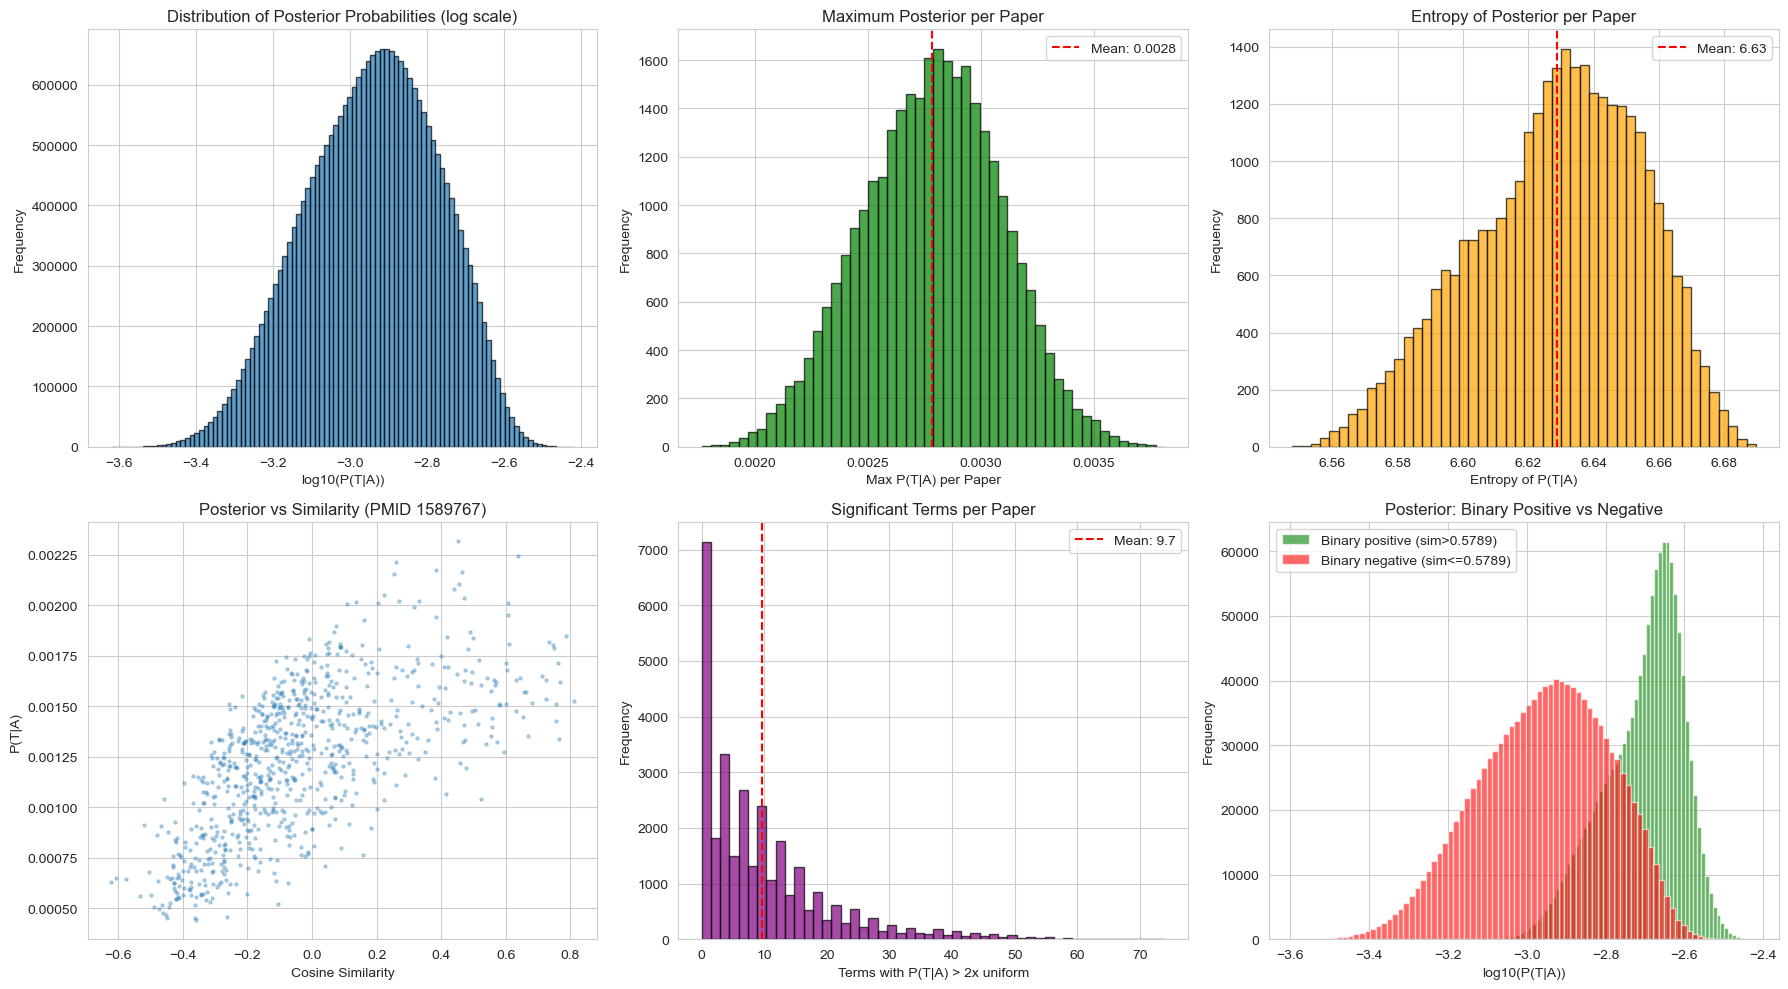


Summary Statistics:
  Max posterior per paper: mean=0.0028, std=0.0003
  Entropy per paper: mean=6.63, std=0.03
  Significant terms per paper (>2x uniform): mean=9.7
  Posterior of binary positives: mean=0.002024
  Posterior of binary negatives: mean=0.001187
  Ratio: 1.7x


In [6]:
"""
Step 11b: Visualize posterior probability distributions.
"""

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall distribution of posterior probabilities (log scale)
nonzero_posteriors = posterior_matrix[posterior_matrix > 0].flatten()
axes[0, 0].hist(np.log10(nonzero_posteriors), bins=100, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('log10(P(T|A))')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Posterior Probabilities (log scale)')

# 2. Top posterior per paper
max_posteriors = posterior_matrix.max(axis=1)
axes[0, 1].hist(max_posteriors, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_xlabel('Max P(T|A) per Paper')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Maximum Posterior per Paper')
axes[0, 1].axvline(max_posteriors.mean(), color='r', linestyle='--',
                    label=f'Mean: {max_posteriors.mean():.4f}')
axes[0, 1].legend()

# 3. Entropy of posterior distribution per paper
from scipy.stats import entropy as scipy_entropy
entropies = np.array([scipy_entropy(posterior_matrix[i]) for i in range(n_papers)])
axes[0, 2].hist(entropies, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 2].set_xlabel('Entropy of P(T|A)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Entropy of Posterior per Paper')
axes[0, 2].axvline(entropies.mean(), color='r', linestyle='--',
                    label=f'Mean: {entropies.mean():.2f}')
axes[0, 2].legend()

# 4. Posterior vs Similarity for a sample paper
sample_idx = 0
axes[1, 0].scatter(similarity_matrix[sample_idx], posterior_matrix[sample_idx],
                    alpha=0.3, s=5)
axes[1, 0].set_xlabel('Cosine Similarity')
axes[1, 0].set_ylabel('P(T|A)')
axes[1, 0].set_title(f'Posterior vs Similarity (PMID {pmid_list_all[0]})')

# 5. Number of "significant" terms per paper (posterior > 1/n_terms, i.e., above uniform)
uniform_threshold = 1.0 / n_terms
significant_per_paper = (posterior_matrix > uniform_threshold * 2).sum(axis=1)
axes[1, 1].hist(significant_per_paper, bins=50, alpha=0.7, edgecolor='black', color='purple')
axes[1, 1].set_xlabel('Terms with P(T|A) > 2x uniform')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Significant Terms per Paper')
axes[1, 1].axvline(significant_per_paper.mean(), color='r', linestyle='--',
                    label=f'Mean: {significant_per_paper.mean():.1f}')
axes[1, 1].legend()

# 6. Compare binary vs continuous for top terms
# Show how posterior probabilities spread across binary positive/negative labels
binary_threshold = 0.5789
binary_positive = similarity_matrix > binary_threshold
posterior_of_positives = posterior_matrix[binary_positive].flatten()
posterior_of_negatives = posterior_matrix[~binary_positive].flatten()

# Sample negatives for plotting (too many)
neg_sample = np.random.choice(posterior_of_negatives,
                               size=min(len(posterior_of_positives), len(posterior_of_negatives)),
                               replace=False)
axes[1, 2].hist(np.log10(posterior_of_positives + 1e-10), bins=80, alpha=0.6,
                label=f'Binary positive (sim>{binary_threshold})', color='green')
axes[1, 2].hist(np.log10(neg_sample + 1e-10), bins=80, alpha=0.6,
                label=f'Binary negative (sim<={binary_threshold})', color='red')
axes[1, 2].set_xlabel('log10(P(T|A))')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Posterior: Binary Positive vs Negative')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics:")
print(f"  Max posterior per paper: mean={max_posteriors.mean():.4f}, std={max_posteriors.std():.4f}")
print(f"  Entropy per paper: mean={entropies.mean():.2f}, std={entropies.std():.2f}")
print(f"  Significant terms per paper (>2x uniform): mean={significant_per_paper.mean():.1f}")
print(f"  Posterior of binary positives: mean={posterior_of_positives.mean():.6f}")
print(f"  Posterior of binary negatives: mean={posterior_of_negatives.mean():.6f}")
print(f"  Ratio: {posterior_of_positives.mean() / posterior_of_negatives.mean():.1f}x")

In [ ]:
"""
Step 11c: Save continuous probability training data.
"""

print("="*80)
print("SAVING CONTINUOUS PROBABILITY TRAINING DATA")
print("="*80)

output_prefix = "cogatlas_term_continuous"

# Build category info
category_info_cont = {
    'concepts': sorted(all_concepts_set & set(all_term_names)),
    'disorders': sorted(all_disorders_set & set(all_term_names)),
    'tasks': sorted(all_tasks_set & set(all_term_names)),
    'term_to_category': {}
}

for term in all_term_names:
    if term in all_concepts_set:
        category_info_cont['term_to_category'][term] = 'concept'
    elif term in all_disorders_set:
        category_info_cont['term_to_category'][term] = 'disorder'
    elif term in all_tasks_set:
        category_info_cont['term_to_category'][term] = 'task'

# Save files
matrix_file = f"{output_prefix}_matrix.npy"
labels_file = f"{output_prefix}_labels.npy"
pmids_file = f"{output_prefix}_pmids.npy"
category_file = f"{output_prefix}_category_info.json"

print(f"\nSaving to:")
print(f"  {matrix_file} (shape: {posterior_matrix.shape}, dtype: float32)")
np.save(matrix_file, posterior_matrix)

print(f"  {labels_file} ({len(all_term_names)} terms)")
np.save(labels_file, np.array(all_term_names))

print(f"  {pmids_file} ({len(pmid_list_all)} papers)")
np.save(pmids_file, np.array(pmid_list_all))

print(f"  {category_file}")
with open(category_file, 'w') as f:
    json.dump(category_info_cont, f, indent=2)

# File sizes
from pathlib import Path
for fname in [matrix_file, labels_file, pmids_file, category_file]:
    size_mb = Path(fname).stat().st_size / 1024 / 1024
    print(f"    {fname}: {size_mb:.1f} MB")

print(f"\n{'='*80}")
print("COMPLETE!")
print(f"{'='*80}")
print(f"\nContinuous probability training data:")
print(f"  Papers:       {n_papers:,}")
print(f"  Terms:        {n_terms}")
print(f"  Matrix shape: {posterior_matrix.shape}")
print(f"  Matrix dtype: {posterior_matrix.dtype}")
print(f"  Value range:  [{posterior_matrix.min():.6f}, {posterior_matrix.max():.6f}]")
print(f"  Row sums:     ~{posterior_matrix.sum(axis=1).mean():.4f} (should be ~1.0)")
print(f"\nFiles saved with prefix: {output_prefix}")
print(f"\nUse these files with neural_network_models_v3.ipynb for regression training.")